<center> </center>

<center><font size=5 face="Helvetica" color=#306998><b>
Meep Tutorial: Bandstructure of Photonic Crystal Slabs
</b></font></center>

<center><font face="Helvetica" size=3><b>Ang Chen</b></font></center>
<center><font face="Helvetica" size=3>January, 2025</font></center>

***

# Import the libraries

In [1]:
# Set the MPLCONFIGDIR environment variable to a temporary directory 
# to avoid issues with Matplotlib configuration in certain environments (e.g., Jupyter notebooks).
# import os
# os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig-nanocompute")

import matplotlib.pyplot as plt
import numpy as np

import meep as mp
from meep import mpb

plt.rcParams["font.family"] = "Helvetica"
%matplotlib inline
%config InlineBackend.figure_format = "svg"


Using MPI version 3.1, 1 processes


# Bands of 2D Photonic Crystal Slabs

## Build the k vector path

In [2]:
def build_mgx_path(nk_mg=13, nk_gx=9):
    """Build the k-point path for the M-X band structure calculation.

    Args:
        nk_mg (int, optional): Point number from M to G (without M and G). Defaults to 13.
        nk_gx (int, optional): Point number from G to X (without G and X). Defaults to 9.

    Returns:
        dict: k_points, path_x, k_parallel, tick_locs, tick_labs
    """
    k_mg = mp.interpolate(
        nk_mg, [mp.Vector3(0.5, 0.5, 0), mp.Vector3(0, 0, 0)])
    k_gx = mp.interpolate(nk_gx, [mp.Vector3(0, 0, 0), mp.Vector3(0.5, 0, 0)])
    k_points = k_mg[:-1] + k_gx

    # Convert k-points to a 2D array for distance calculations
    k_xy = np.array([[k.x, k.y] for k in k_points], dtype=float)
    # Calculate the cumulative distance along the k-point path
    dk = np.linalg.norm(np.diff(k_xy, axis=0), axis=1)
    # Create the x-axis values for plotting the band structure
    path_x = np.concatenate([[0.0], np.cumsum(dk)])
    # Calculate the parallel component of the k-points for plotting
    k_parallel = np.linalg.norm(k_xy, axis=1)

    tick_locs = [path_x[0], path_x[len(k_mg) - 1], path_x[-1]]
    tick_labs = ["M", r"$\Gamma$", "X"]
    return {
        "k_points": k_points,
        "path_x": path_x,
        "k_parallel": k_parallel,
        "tick_locs": tick_locs,
        "tick_labs": tick_labs,
    }

## Parameters

In [3]:
n_slab = 2.02  # Silicon Nitride (Si3N4)
n_clad = 1.46  # Silicon Dioxide (SiO2)

a_nm = 336.0  # Lattice constant in nanometers
slab_thickness = 180.0 / a_nm  # Slab thickness in units of the lattice constant
hole_radius = 80.0 / a_nm  # Hole radius in units of the lattice constant

In [4]:
path = build_mgx_path()
len(path["k_points"]), path["tick_locs"]

(25, [0.0, 0.7071067811865474, 1.2071067811865477])

## MPB Supercell Calculation

Using MPB to calculate z-even / z-odd bands along M-$\Gamma$ with $\text{SiO}_2$ light line.

Summary:
- **Blow the light line**：MPB can give stable frequencies of guided modes.
- **Above the light line**：MPB can still give the eigenvalues of some real frequencies, but mixed with radiative continuum spectra after supercell discretization; these can't be regarded as real leaky-mode bands without radiative loss or Q factor.

In [5]:
def build_mpb_solver(supercell_z=8.0, resolution=24, num_bands=10, k_points=None):
    """Get a mpb object for calculating the bands of a 2D phtonic crystal slab with MPB sover.

    Args:
        supercell_z (float, optional): Period of z direction. Defaults to 8.0.
        resolution (int, optional): Resolution of the grid. Defaults to 24.
        num_bands (int, optional): Number of the bands to be calculated. Defaults to 10.
        k_points (list, optional): List of k points from meep. Defaults to None.

    Returns:
        mpb ModeSolver object
    """
    if k_points is None:
        k_points = path["k_points"]

    geometry_lattice = mp.Lattice(size=mp.Vector3(1, 1, supercell_z))
    geometry = [
        mp.Block(
            center=mp.Vector3(),
            size=mp.Vector3(mp.inf, mp.inf, slab_thickness),
            material=mp.Medium(index=n_slab),
        ),
        mp.Cylinder(
            center=mp.Vector3(),
            radius=hole_radius,
            height=slab_thickness,
            material=mp.Medium(index=n_clad),
        ),
    ]

    return mpb.ModeSolver(
        geometry_lattice=geometry_lattice,
        geometry=geometry,
        resolution=resolution,
        num_bands=num_bands,
        k_points=k_points,
        default_material=mp.Medium(index=n_clad),
    )


def run_mpb_bands(supercell_z=8.0, resolution=24, num_bands=10):
    """Calculate the bands of a 2D phtonic crystal slab with MPB sover.

    Args:
        supercell_z (float, optional): Period of z direction. Defaults to 8.0.
        resolution (int, optional): Resolution of the grid. Defaults to 24.
        num_bands (int, optional): Number of the bands to be calculated. Defaults to 10.

    Returns:
        Two numpy.ndarray: _description_
    """
    ms = build_mpb_solver(
        supercell_z=supercell_z,
        resolution=resolution,
        num_bands=num_bands,
        k_points=path["k_points"],
    )
    ms.run_zeven()
    even_freqs = np.array(ms.all_freqs)
    ms.run_zodd()
    odd_freqs = np.array(ms.all_freqs)

    return even_freqs, odd_freqs

In [6]:
# Parameters
supercell_z_mpb = 1.0
resolution_mpb = 24
num_bands_mpb = 5

mpb_even_freqs, mpb_odd_freqs = run_mpb_bands(
    supercell_z=supercell_z_mpb, resolution=resolution_mpb, num_bands=num_bands_mpb)

Initializing eigensolver data
Computing 5 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 24 x 24 x 24.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1e+20,0.535714)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.238095, height 0.535714, axis (0, 0, 1)
Geometric object tree has depth 1 and 10 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zeven.
Initializing fields to random numbers...
25 k-points
  Vector3<0.5, 0.5, 0.0>
  Vector3<0.4642857142857143, 0.4642857142857143, 0.0>
  Vector3<0.4285714285714286, 0.4285714285714286, 0.0>
  Vector3<0.39285714285714285, 0.39285714285714285, 0.0>
  Vector3<0

In [7]:
mpb_even_freqs.shape, mpb_odd_freqs.shape

((25, 5), (25, 5))

In [8]:
def plot_mpb_bands(even_freqs, odd_freqs, ymax=0.7):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    light_line = path["k_parallel"] / n_clad

    first_odd_above_ll = None
    first_crossing_idx = None
    for band_idx in range(odd_freqs.shape[1]):
        above = np.where(odd_freqs[:, band_idx] > light_line)[0]
        if len(above) == 0:
            continue
        crossing_idx = int(above[0])
        if first_crossing_idx is None or crossing_idx < first_crossing_idx:
            first_crossing_idx = crossing_idx
            first_odd_above_ll = band_idx

    for band_idx in range(even_freqs.shape[1]):
        ax.plot(
            path["path_x"],
            even_freqs[:, band_idx],
            linestyle="--",
            color="black",
            lw=1.2,
            label="z-even (TE-like)" if band_idx == 0 else None,
        )

    for band_idx in range(odd_freqs.shape[1]):
        odd_color = "green" if band_idx == 1 else "black"
        if band_idx == first_odd_above_ll == 0:
            odd_label = "z-odd (TM-like), first above light line"
        elif band_idx == 1:
            odd_label = "first z-odd above light line"
        elif band_idx == 0:
            odd_label = "z-odd (TM-like)"
        else:
            odd_label = None
        ax.plot(
            path["path_x"],
            odd_freqs[:, band_idx],
            linestyle="-",
            color=odd_color,
            lw=1.2,
            label=odd_label,
        )

    ax.fill_between(
        path["path_x"],
        light_line,
        ymax,
        color="#F0EFA6",
        alpha=0.8,
        label="SiO$_2$ light cone",
    )

    ax.set_xlim(path["path_x"][0], path["path_x"][-1])
    ax.set_ylim(0.0, ymax)
    ax.set_xticks(path["tick_locs"])
    ax.set_xticklabels(path["tick_labs"], size=12)
    ax.set_xlabel("Wave vector", size=12)
    ax.set_ylabel(r"Frequency $\omega a / 2\pi c$", size=12)
    for x in path["tick_locs"]:
        ax.axvline(x, color="#999999", lw=1)
    ax.legend(loc="lower left")
    fig.tight_layout()


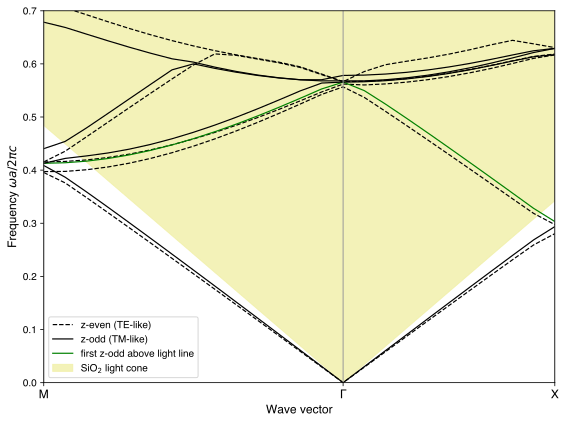

In [9]:
plot_mpb_bands(mpb_even_freqs, mpb_odd_freqs)

Do convergence test with changing the height of supercell along z direction:
- Real guided modes don't depend on the supercell z height.
- Radiative continuum spectra depend on the supercell z height after supercell height discretization.


In [10]:
# Probe the band frequencies at a specific k point along G-X direction.
probe_k = mp.Vector3(0.35, 0.0, 0.0)
probe_light_line = np.sqrt(probe_k.x**2 + probe_k.y**2) / n_clad


def probe_mpb_supercell_dependence(k_point, supercell_z_values=(4.0, 6.0, 8.0), 
                                resolution=20, num_bands=6, mode_parity='even'):
    rows = []
    for supercell_z in supercell_z_values:
        ms = build_mpb_solver(
            supercell_z=supercell_z,
            resolution=resolution,
            num_bands=num_bands,
            k_points=[k_point],
        )
        if mode_parity.lower() == 'even':
            ms.run_zeven()
        elif mode_parity.lower() == 'odd':
            ms.run_zodd()

        freqs = np.array(ms.all_freqs)[0]
        rows.append((supercell_z, freqs))

    return rows

In [11]:
mpb_probe_rows = probe_mpb_supercell_dependence(k_point=probe_k, supercell_z_values=(1.0, 2.0,4.0, 6.0, 8.0))
mpb_probe_rows

Initializing eigensolver data
Computing 6 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 20 x 20 x 20.
Solving for 6 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1e+20,0.535714)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.238095, height 0.535714, axis (0, 0, 1)
Geometric object tree has depth 1 and 10 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zeven.
Initializing fields to random numbers...
1 k-points
  Vector3<0.35, 0.0, 0.0>
elapsed time for initialization: 0.016146183013916016
solve_kpoint (0.35,0,0):
zevenfreqs:, k index, k1, k2, k3, kmag/2pi, zeven band 1, zeven band 2, zeven band 3, zeven band 4,

[(1.0,
  array([0.20261752, 0.37387356, 0.59147274, 0.59716658, 0.63460076,
         0.63584623])),
 (2.0,
  array([0.21667917, 0.37171523, 0.38167393, 0.39451153, 0.51468786,
         0.52404783])),
 (4.0,
  array([0.22364582, 0.27475225, 0.285637  , 0.39057021, 0.39921179,
         0.40124085])),
 (6.0,
  array([0.22525655, 0.25365644, 0.26224589, 0.31719591, 0.3221383 ,
         0.39364462])),
 (8.0,
  array([0.22566206, 0.24666996, 0.25304235, 0.28485153, 0.28988456,
         0.34069473]))]

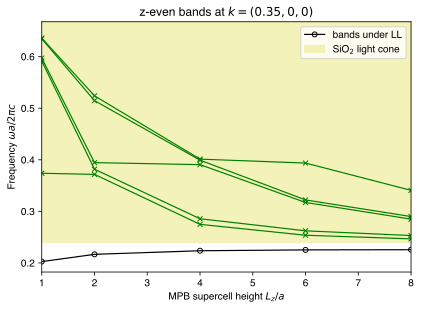

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

sz_values = [row[0] for row in mpb_probe_rows]
num_probe_bands = len(mpb_probe_rows[0][1])

for band_idx in range(num_probe_bands):
    band_values = [row[1][band_idx] for row in mpb_probe_rows]
    ax.plot(
        sz_values,
        band_values,
        lw=1.2,
        marker="o" if band_idx == 0 else "x",
        markerfacecolor="none",
        markersize=5,
        color = "black" if band_idx == 0 else "g",
        label = "bands under LL" if band_idx == 0 else None,
    )
ymin = np.min(mpb_probe_rows[0][1]*0.9)
ymax = np.max(band_values)*1.05
ax.fill_between(
        sz_values,
        probe_light_line,
        ymax,
        color="#F0EFA6",
        alpha=0.8,
        label="SiO$_2$ light cone",
    )
ax.set_xlim(np.min(sz_values), np.max(sz_values))
ax.set_ylim(ymin, ymax)

ax.set_xlabel("MPB supercell height $L_z / a$")
ax.set_ylabel(r"Frequency $\omega a / 2\pi c$")
ax.set_title(r"z-even bands at $k=(0.35, 0, 0)$")
ax.legend(loc="best")

fig.tight_layout()

## Meep solve_eigfreq one-point test

From above：
- First band under LL is basically stable.
- Higher bands are slab guided modes, unstable when changing the z of supercell.

Hence, `MPB` can only obtain stable modes under LL;
if obtaining leaky modes above LL, `Meep` method with `run_k_points + Harminv` should be adopted.


### One k point test

The full fixed-`k` continuation run is still expensive because each branch seed at each `k` point launches a separate 3D frequency-domain solve.  
Before continuing to a full band sweep, it is better to test `solve_eigfreq` at **one** representative `k` point and confirm:

- which seed guesses converge cleanly,
- which parity sector they belong to,
- whether the solved frequency lies below or above the silica light line,
- and what `Q` value Meep returns from the complex eigenfrequency.

This notebook section is therefore reduced to a **single-k solve_eigfreq test** with extra comments.

The solver settings below are intentionally conservative on runtime: only two seed guesses and a reduced solver budget.


In [26]:
# Choose one representative k point for the first eigfreq test.
# This is the same point used earlier in the MPB supercell probe.
#
# k = (0.35, 0.0, 0.0) is useful because:
# 1. it is away from Gamma, so the light line is not too close to zero;
# 2. earlier tests already showed interesting slab modes here;
# 3. it is cheap enough to study carefully before doing a full path sweep.
solve_k_point = mp.Vector3(0.0, 0.0, 0.0)
solve_k_parallel = np.sqrt(solve_k_point.x**2 + solve_k_point.y**2)
solve_light_line = solve_k_parallel / n_clad

{
    "k_point": (solve_k_point.x, solve_k_point.y, solve_k_point.z),
    "k_parallel": solve_k_parallel,
    "light_line": solve_light_line,
}


{'k_point': (0.0, 0.0, 0.0), 'k_parallel': 0.0, 'light_line': 0.0}

In [27]:
def build_meep_eig_sources(parity, guessfreq):
    """Build parity-selective continuous-wave sources for one eigfreq solve.

    solve_eigfreq finds one complex eigenfrequency near guessfreq.
    The source is only used to define the driven CW problem that the
    eigensolver iterates around; unlike the Harminv workflow, we do not sweep
    a broad bandwidth here.

    Parameters
    ----------
    parity:
        "even" for z-even modes, "odd" for z-odd modes.
    guessfreq:
        Initial frequency guess for the targeted resonance.
    """
    # Put the source away from symmetry planes and the hole center so that the
    # targeted mode is less likely to have a field node exactly at the source.
    src_center = mp.Vector3(0.173, 0.117, 0.09)

    # solve_eigfreq is a frequency-domain method, so we use a continuous-wave
    # source at the current frequency guess instead of a broadband pulse.
    cw = mp.ContinuousSource(frequency=float(np.real(guessfreq)))

    if parity == "even":
        # z-even sector: Ex and Ey are natural in-plane excitations.
        symmetries = [mp.Mirror(mp.Z, phase=+1)]
        sources = [
            mp.Source(cw, component=mp.Ex, center=src_center),
            mp.Source(cw, component=mp.Ey, center=src_center),
        ]
    elif parity == "odd":
        # z-odd sector: Ez is the simplest out-of-plane excitation.
        symmetries = [mp.Mirror(mp.Z, phase=-1)]
        sources = [
            mp.Source(cw, component=mp.Ez, center=src_center),
        ]
    else:
        raise ValueError("parity must be 'even' or 'odd'")

    return symmetries, sources


def build_meep_eig_sim(k_point, parity, guessfreq, supercell_z=6.0, resolution=16):
    """Construct one fixed-k Meep simulation for solve_eigfreq.

    Notes
    -----
    - x and y remain Bloch-periodic through k_point.
    - z is open through a PML so leaky slab modes can radiate.
    - force_complex_fields=True is required because resonant frequencies are complex.
    """
    symmetries, sources = build_meep_eig_sources(parity=parity, guessfreq=guessfreq)

    return mp.Simulation(
        cell_size=mp.Vector3(1, 1, supercell_z),
        geometry=[
            mp.Block(
                center=mp.Vector3(),
                size=mp.Vector3(mp.inf, mp.inf, slab_thickness),
                material=mp.Medium(index=n_slab),
            ),
            mp.Cylinder(
                center=mp.Vector3(),
                radius=hole_radius,
                height=slab_thickness,
                material=mp.Medium(index=n_clad),
            ),
        ],
        boundary_layers=[mp.PML(1.0, direction=mp.Z)],
        sources=sources,
        resolution=resolution,
        default_material=mp.Medium(index=n_clad),
        symmetries=symmetries,
        force_complex_fields=True,
        k_point=k_point,
    )


def q_from_eigfreq(eigfreq):
    """Convert a complex eigenfrequency to Q.

    Meep returns eigfreq = omega_real + i * omega_imag.
    For a decaying resonance, omega_imag is typically negative.
    We report a positive Q by taking the absolute value.
    """
    if not np.isfinite(np.real(eigfreq)) or not np.isfinite(np.imag(eigfreq)):
        return np.nan
    if abs(np.imag(eigfreq)) < 1e-12:
        return np.inf
    return abs(np.real(eigfreq) / (2 * np.imag(eigfreq)))


def solve_mode_at_k(
    k_point,
    parity,
    guessfreq,
    supercell_z=6.0,
    resolution=16,
    tol=1e-6,
    maxiters=20,
    cwtol=1e-8,
    cwmaxiters=2000,
    L=10,
):
    """Solve one complex resonance near guessfreq at one fixed k point.

    Parameters
    ----------
    tol, maxiters:
        Outer eigensolver tolerance and iteration limit.
    cwtol, cwmaxiters:
        Inner CW linear-solver tolerance and iteration limit.
    L:
        Meep preconditioner parameter for the CW solve.

    Returns
    -------
    dict with frequency, imaginary part, Q, and a few diagnostics.
    """
    sim = build_meep_eig_sim(
        k_point=k_point,
        parity=parity,
        guessfreq=guessfreq,
        supercell_z=supercell_z,
        resolution=resolution,
    )

    # Fields must be initialized before calling solve_eigfreq.
    sim.init_sim()

    eigfreq = sim.solve_eigfreq(
        tol=tol,
        maxiters=maxiters,
        guessfreq=guessfreq,
        cwtol=cwtol,
        cwmaxiters=cwmaxiters,
        L=L,
    )

    freq = float(np.real(eigfreq))
    freq_im = float(np.imag(eigfreq))
    q_value = q_from_eigfreq(eigfreq)

    return {
        "parity": parity,
        "guessfreq": float(np.real(guessfreq)),
        "eigfreq": eigfreq,
        "freq": freq,
        "freq_im": freq_im,
        "Q": q_value,
        "below_light_line": bool(freq < solve_light_line),
    }


In [28]:
# Test a small set of seed guesses at the single chosen k point.
#
# Important: solve_eigfreq returns one nearby resonance per guess.
# If two guesses converge to the same mode, that is still useful information:
# it means the current seeds are redundant and should be refined.
#
# These guesses are intentionally few in number to keep the runtime short.
one_point_seed_specs = [
    {"parity": "even", "label": "z-even trial", "guessfreq": 0.62},
    {"parity": "odd", "label": "z-odd trial", "guessfreq": 0.64},
]

# Solver settings are intentionally modest for this first test.
# If convergence is poor, the next step is to increase cwmaxiters and/or improve
# the seed guesses before increasing the number of k points.
one_point_solver_settings = {
    "supercell_z": 6.0,
    "resolution": 12,
    "tol": 1e-5,
    "maxiters": 8,
    "cwtol": 1e-7,
    "cwmaxiters": 600,
    "L": 8,
}

one_point_results = []
for spec in one_point_seed_specs:
    result = solve_mode_at_k(
        solve_k_point,
        parity=spec["parity"],
        guessfreq=spec["guessfreq"],
        **one_point_solver_settings,
    )
    result["label"] = spec["label"]
    one_point_results.append(result)

one_point_results


-----------
Initializing structure...
Halving computational cell along direction z
time for choose_chunkdivision = 0.000523 s
Working in 3D dimensions.
Computational cell is 1 x 1 x 6 with resolution 12
     block, center = (0,0,0)
          size (1e+20,1e+20,0.535714)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.0804,4.0804,4.0804)
     cylinder, center = (0,0,0)
          radius 0.238095, height 0.535714, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (2.1316,2.1316,2.1316)
time for set_epsilon = 0.01456 s
-----------
Meep: using complex fields.
on time step 4432 (time=184.667), 0.00090262 s/step
residual[279] = 0.00937785
on time step 9485 (time=395.208), 0.00079168 s/step
residual[595] = 2.0449e-06
final residual = 2.54631e-06
Finished solve_cw after 600 CG iters (~ 9600 timesteps).
 -- CONVERGENCE FAILURE (1) in solve_cw!
Initial eigen-frequency estimate = 0.488163-0.0109284i
on time step 14623 (time=609.292), 0.0007

[{'parity': 'even',
  'guessfreq': 0.62,
  'eigfreq': (0.5818703402002928-0.001136333046676321j),
  'freq': 0.5818703402002928,
  'freq_im': -0.001136333046676321,
  'Q': 256.0298417361947,
  'below_light_line': False,
  'label': 'z-even trial'},
 {'parity': 'odd',
  'guessfreq': 0.64,
  'eigfreq': (0.6120157488291066-1.1502825601428168e-05j),
  'freq': 0.6120157488291066,
  'freq_im': -1.1502825601428168e-05,
  'Q': 26602.843946148325,
  'below_light_line': False,
  'label': 'z-odd trial'}]

In [33]:
# Reformat the raw results into a compact table that is easier to read.
one_point_summary = [
    {
        "label": row["label"],
        "parity": row["parity"],
        "guessfreq": row["guessfreq"],
        "freq": row["freq"],
        "freq_im": row["freq_im"],
        "Q": row["Q"],
        "below_light_line": row["below_light_line"],
    }
    for row in sorted(one_point_results, key=lambda item: (item["parity"], item["freq"]))
]

one_point_summary


[{'label': 'z-even trial',
  'parity': 'even',
  'guessfreq': 0.62,
  'freq': 0.5818703402002928,
  'freq_im': -0.001136333046676321,
  'Q': 256.0298417361947,
  'below_light_line': False},
 {'label': 'z-odd trial',
  'parity': 'odd',
  'guessfreq': 0.64,
  'freq': 0.6120157488291066,
  'freq_im': -1.1502825601428168e-05,
  'Q': 26602.843946148325,
  'below_light_line': False}]

In [34]:
# Keep the single-k result in a dictionary with the light line so that the
# relationship between each solved mode and the light cone is explicit.
one_point_result_table = {
    "k_point": (solve_k_point.x, solve_k_point.y, solve_k_point.z),
    "light_line": float(solve_light_line),
    "modes": one_point_summary,
}

one_point_result_table


{'k_point': (0.0, 0.0, 0.0),
 'light_line': 0.0,
 'modes': [{'label': 'z-even trial',
   'parity': 'even',
   'guessfreq': 0.62,
   'freq': 0.5818703402002928,
   'freq_im': -0.001136333046676321,
   'Q': 256.0298417361947,
   'below_light_line': False},
  {'label': 'z-odd trial',
   'parity': 'odd',
   'guessfreq': 0.64,
   'freq': 0.6120157488291066,
   'freq_im': -1.1502825601428168e-05,
   'Q': 26602.843946148325,
   'below_light_line': False}]}

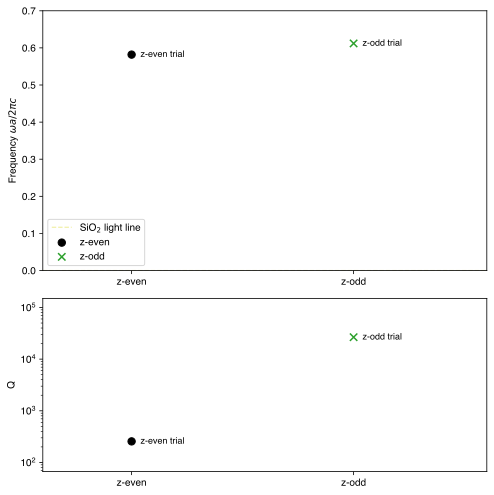

In [35]:
def plot_one_point_solve_eigfreq_results(results):
    """Plot the solved resonances at one k point together with the light line."""
    fig, (ax_band, ax_q) = plt.subplots(
        2,
        1,
        figsize=(7, 7),
        gridspec_kw={"height_ratios": [3, 2]},
    )

    # Horizontal reference for the silica light line at this k point.
    ax_band.axhline(solve_light_line, color="#F0EFA6", lw=1.2, linestyle="--", label="SiO$_2$ light line")

    # Separate even and odd sectors by x position so the single-point solve is readable.
    x_positions = {"even": 0.0, "odd": 1.0}
    colors = {"even": "black", "odd": "tab:green"}
    markers = {"even": "o", "odd": "x"}

    q_values = []
    even_labeled = False
    odd_labeled = False

    for row in results:
        x = x_positions[row["parity"]]
        q_values.append(row["Q"])

        ax_band.scatter(
            x,
            row["freq"],
            color=colors[row["parity"]],
            marker=markers[row["parity"]],
            s=55,
            label=("z-even" if not even_labeled else None) if row["parity"] == "even" else ("z-odd" if not odd_labeled else None),
        )
        ax_band.text(x + 0.04, row["freq"], row["label"], fontsize=9, va="center")

        ax_q.scatter(
            x,
            row["Q"],
            color=colors[row["parity"]],
            marker=markers[row["parity"]],
            s=55,
        )
        ax_q.text(x + 0.04, row["Q"], row["label"], fontsize=9, va="center")

        if row["parity"] == "even":
            even_labeled = True
        else:
            odd_labeled = True

    ax_band.set_xlim(-0.4, 1.6)
    ax_band.set_ylim(0.0, 0.7)
    ax_band.set_xticks([0.0, 1.0])
    ax_band.set_xticklabels(["z-even", "z-odd"])
    ax_band.set_ylabel(r"Frequency $\omega a / 2\pi c$")
    ax_band.legend(loc="best")

    finite_q = np.array([q for q in q_values if np.isfinite(q) and q > 0], dtype=float)
    ax_q.set_yscale("log")
    if finite_q.size:
        q_floor = 10 ** np.floor(np.log10(np.nanmin(finite_q)))
        q_ceil = 10 ** np.ceil(np.log10(np.nanmax(finite_q)))
        ax_q.set_ylim(max(1e1, q_floor / 1.5), q_ceil * 1.5)
    ax_q.set_xlim(-0.4, 1.6)
    ax_q.set_xticks([0.0, 1.0])
    ax_q.set_xticklabels(["z-even", "z-odd"])
    ax_q.set_ylabel("Q")

    fig.tight_layout()


plot_one_point_solve_eigfreq_results(one_point_summary)


In [32]:
one_point_summary


[{'label': 'z-even trial',
  'parity': 'even',
  'guessfreq': 0.62,
  'freq': 0.5818703402002928,
  'freq_im': -0.001136333046676321,
  'Q': 256.0298417361947,
  'below_light_line': False},
 {'label': 'z-odd trial',
  'parity': 'odd',
  'guessfreq': 0.64,
  'freq': 0.6120157488291066,
  'freq_im': -1.1502825601428168e-05,
  'Q': 26602.843946148325,
  'below_light_line': False}]

## What to take away

This one-point test answers three practical questions before any full band sweep:

1. **Does `solve_eigfreq` converge cleanly at this `k` point?**
2. **Which seed guesses land on distinct modes, and which guesses are redundant?**
3. **Are the solved modes below or above the light line, and what `Q` values do they have?**

Only after this single-k test looks reasonable should we continue to a multi-k branch-tracking calculation.
